In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# === Replaced: Use MobileNetV3-Large instead of ResNet-18 ===
import torch.nn as nn
try:
    from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
    weights = MobileNet_V3_Large_Weights.DEFAULT
    model = mobilenet_v3_large(weights=weights)
except Exception:
    # Fallback for older torchvision versions
    from torchvision import models
    model = models.mobilenet_v3_large(pretrained=True)

# Replace classifier head to match num_classes
# MobileNetV3-Large has model.classifier = Sequential(Linear(960,1280), Hardswish, Dropout, Linear(1280,1000))
in_feats = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_feats, num_classes)

model = model.to(device)
print("[Backbone] MobileNetV3-Large")
print(model.classifier)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os

# ======== Parameters ========
num_classes = len(os.listdir('patches_only'))  # Same as training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======== Define Transforms (same as training) ========
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ======== Load Model ========
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("resnet18_density_classifier.pth", map_location=device))
model = model.to(device)
model.eval()

# ======== Load Image and Preprocess ========
img_path = "patches_only/21-30/SA-1-C-4.png"
image = Image.open(img_path).convert("RGB")
image = transform(image).unsqueeze(0).to(device)  # Add batch dimension

# ======== Forward Pass + Softmax ========
with torch.no_grad():
    outputs = model(image)
    probs = torch.softmax(outputs, dim=1)  # Get probability distribution
    probs = probs.cpu().numpy().flatten()

# ======== Print Probabilities ========
for i, prob in enumerate(probs):
    print(f"Class {i}: {prob:.4f}")


Class 0: 0.0000
Class 1: 0.0000
Class 2: 1.0000
Class 3: 0.0000
Class 4: 0.0000
Class 5: 0.0000
Class 6: 0.0000
Class 7: 0.0000
Class 8: 0.0000
Class 9: 0.0000
Class 10: 0.0000


In [ ]:
import os
import shutil
import random

def split_dataset(source_dir, output_dir, train_ratio=0.8):
    random.seed(42)  # for reproducibility

    # Create train and test directories
    train_dir = os.path.join(output_dir, 'train')
    test_dir = os.path.join(output_dir, 'test')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.endswith('.png')]
        random.shuffle(images)

        split_index = int(len(images) * train_ratio)
        train_images = images[:split_index]
        test_images = images[split_index:]

        # Create class subfolders in train and test directories
        train_class_dir = os.path.join(train_dir, class_name)
        test_class_dir = os.path.join(test_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(test_class_dir, exist_ok=True)

        # Copy files
        for img in train_images:
            shutil.copy2(os.path.join(class_path, img), os.path.join(train_class_dir, img))

        for img in test_images:
            shutil.copy2(os.path.join(class_path, img), os.path.join(test_class_dir, img))

        print(f"Processed class '{class_name}': {len(train_images)} train, {len(test_images)} test")

# Example usage
source_directory = 'patches_only'
output_directory = 'patches_only_split'
split_dataset(source_directory, output_directory)


Processed class 'Organic-v early stage': 34 train, 9 test
Processed class 'Organic': 46 train, 12 test
Processed class 'Organic-early stage': 36 train, 10 test
Processed class 'WatPhlang_2': 320 train, 81 test
Processed class 'triple_dense_grown': 52 train, 13 test
Processed class 'Karavatti_1': 72 train, 18 test
Processed class 'triple_less_dense_grown': 38 train, 10 test
Processed class 'triple_dense_small': 7 train, 2 test
Processed class 'triple_less_dense_small': 1 train, 1 test
Processed class 'WatPhlang_1': 680 train, 171 test


/opt/miniconda3/envs/hack2/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/hack2/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<Figure size 3000x3000 with 0 Axes>

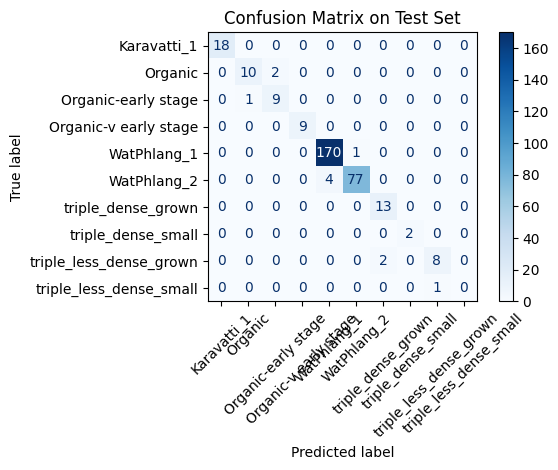

In [ ]:
import torch
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import os

# ======== Parameters ========
test_dir = 'patches_only_split/test'
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======== Transforms ========
test_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ======== Load Test Dataset ========
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = test_dataset.classes
num_classes = len(class_names)

# ======== Load Model ========
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("resnet18_density_classifier.pth", map_location=device))
model.to(device)
model.eval()

# ======== Inference and Collect Predictions ========
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ======== Confusion Matrix ========
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(30, 30))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


/opt/miniconda3/envs/hack2/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/hack2/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<Figure size 1200x1200 with 0 Axes>

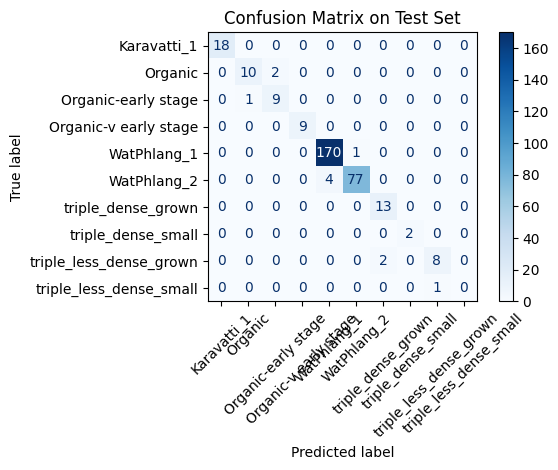

Found 11 misclassified images.


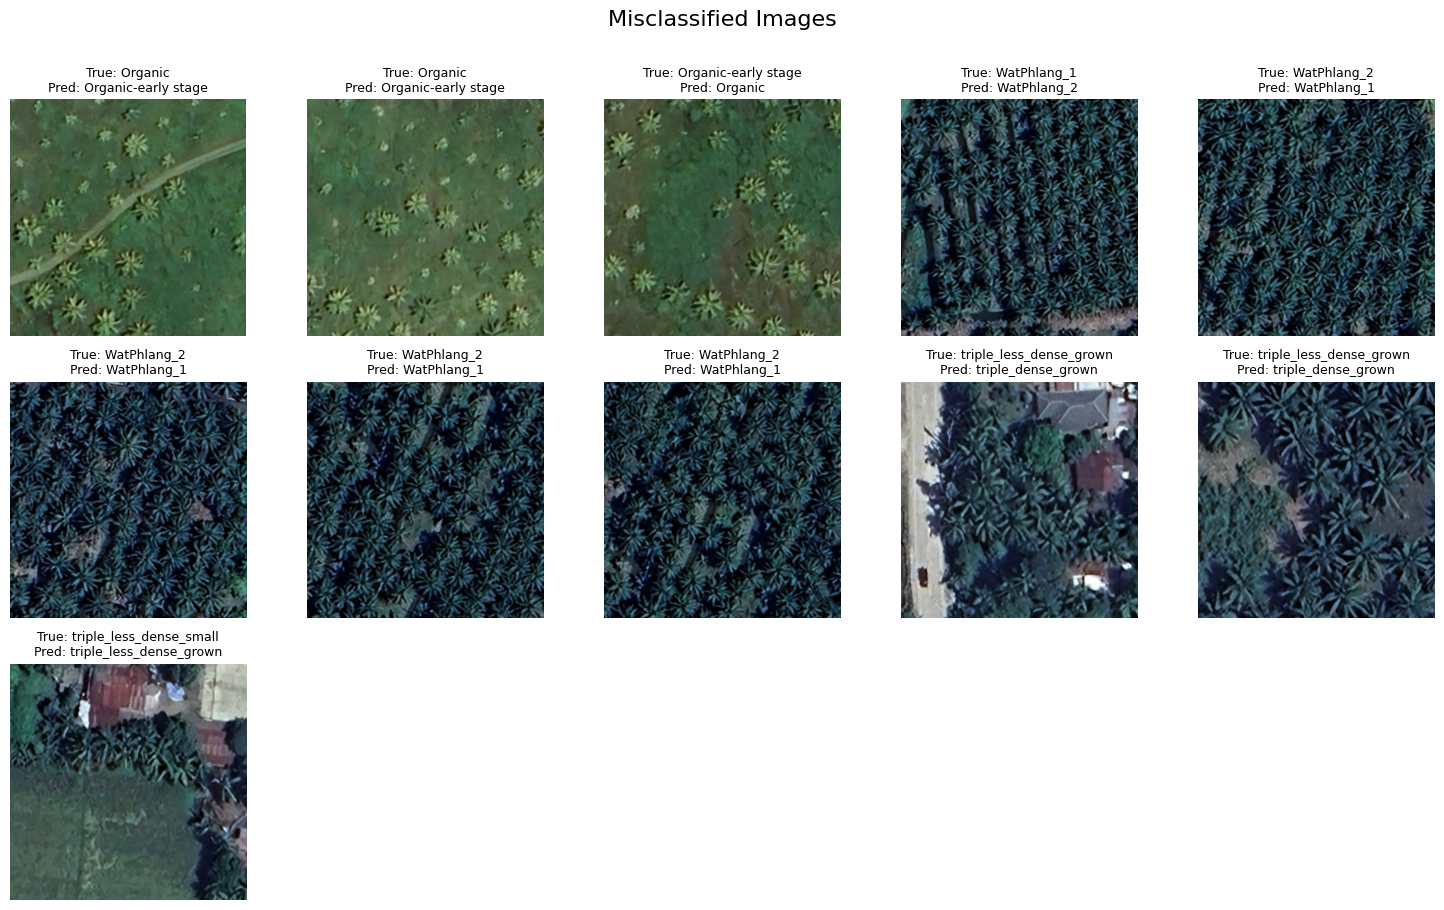

In [ ]:
import torch
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import os

# ======== Parameters ========
test_dir = 'patches_only_split/test'
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======== Transforms ========
test_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ======== Load Test Dataset ========
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = test_dataset.classes
num_classes = len(class_names)

# ======== Load Model ========
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("resnet18_density_classifier.pth", map_location=device))
model.to(device)
model.eval()

# ======== Inference and Collect Predictions ========
all_preds = []
all_labels = []
all_paths = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Get paths from dataset.samples (keeps order with shuffle=False)
all_paths = [s[0] for s in test_dataset.samples]

# ======== Confusion Matrix ========
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()

# ======== Plot Misclassified Images ========
misclassified_indices = [i for i, (pred, true) in enumerate(zip(all_preds, all_labels)) if pred != true]

if not misclassified_indices:
    print("No misclassifications found.")
else:
    print(f"Found {len(misclassified_indices)} misclassified images.")

    # Show up to 25 misclassified images
    num_to_show = min(25, len(misclassified_indices))
    plt.figure(figsize=(15, 15))

    for i, idx in enumerate(misclassified_indices[:num_to_show]):
        image_path = all_paths[idx]
        image = plt.imread(image_path)

        plt.subplot(5, 5, i + 1)
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}", fontsize=9)

    plt.tight_layout()
    plt.suptitle("Misclassified Images", fontsize=16)
    plt.subplots_adjust(top=0.92)
    plt.show()
